# High-Throughput Neural Super-Sampling on Kaggle (T4 x 2)

End-to-end single-image and video super-resolution (Rep-TNSR v2 trunk) using ONLY the Kaggle-native datasets from RESEARCH.md section 3.2. Companion notebook `neural_frame_generation.ipynb` covers the NeuralFG frame-generation track on the same inputs.

## Kaggle setup (2 minutes)

1. Settings > Accelerator > GPU T4 x 2.
2. + Add Input > attach any of the RESEARCH.md datasets below (at least one image/video set). Suggested starter: `soumikrakshit/div2k-high-resolution-images` + `uom200647r/vid4-dataset` (held-out) + `jesucristo/super-resolution-benchmarks` (held-out). For a <15 min smoke test attach only `cookiemonsteryum/reds-video-superresolution-toy-dataset` and set `quick_run = True` in the config cell.
3. Keep Internet OFF. This notebook uses /kaggle/input only and installs nothing.
4. Run All. Outputs go to /kaggle/working/outputs, checkpoints to /kaggle/working/checkpoints.

## What it does

- Auto-discovers images under /kaggle/input in any folder layout.
- Builds paired LR-HR data on the fly with bicubic downsampling at scale 3.
- Trains a reparameterisable trunk (multi-branch train, single 3x3 fuse at export).
- Uses FP16 AMP, DataParallel on 2x T4, tuned DataLoader, cuDNN benchmark, channels-last, optional torch.compile.
- Validates each epoch, checkpoints best and last, resumes on re-run.
- Reports PSNR and SSIM with plots, tables, prediction grids, error maps, latency and VRAM benchmarks.
- Exports fused weights plus ONNX.

## Datasets used (RESEARCH.md section 3.2 only, nothing else)

| Slug | Mount | Role here |
| :--- | :--- | :--- |
| `soumikrakshit/div2k-high-resolution-images` | `/kaggle/input/div2k-high-resolution-images` | spatial warmup training |
| `daehoyang/flickr2k` | `/kaggle/input/flickr2k` | spatial pretraining pool |
| `itzloghotxd/df2k-ost` | `/kaggle/input/df2k-ost` | scaled spatial training |
| `yashchoudhary/realsr-v3` | `/kaggle/input/realsr-v3` | real-world robustness training |
| `amithkesavmrajagiri/reds-dataset` | `/kaggle/input/reds-dataset` | video SR training (frames treated as images + sequence-aware splits) |
| `cookiemonsteryum/reds-video-superresolution-toy-dataset` | `/kaggle/input/reds-video-superresolution-toy-dataset` | <15 min smoke test |
| `artemmmtry/mpi-sintel-dataset` | `/kaggle/input/mpi-sintel-dataset` | RGB training (flow/depth files ignored here, used in FG notebook) |
| `wangsally/vimeo-90k-7` | `/kaggle/input/vimeo-90k-7` | multi-frame training frames |
| `chenshu123/vimeo-triplet` | `/kaggle/input/vimeo-triplet` | training frames |
| `craljimenez/flyingchairs` | `/kaggle/input/flyingchairs` | training frames (`.ppm` supported, `.flo` ignored here) |
| `uom200647r/vid4-dataset` | `/kaggle/input/vid4-dataset` | HELD-OUT benchmark only, never trained on |
| `jesucristo/super-resolution-benchmarks` | `/kaggle/input/super-resolution-benchmarks` | HELD-OUT Set5/Set14/B100/Urban100/Manga109, never trained on |

## Adaptation note

The research spec uses 12-channel G-buffer input. Public Kaggle mirrors provide RGB only, so the same trunk trains on 3-channel RGB here. Motion vectors and frame generation are covered by a synthetic-pan consistency demo plus an untrained NeuralFG wiring check. With G-buffer renders, widen the input back to 12 channels.

## Run order

0 bootstrap, 1 logging, 2 config (`quick_run` flag), 3 hardware, 4 discovery (with held-out exclusion), 5 EDA, 6 loaders (sequence-aware splits), 7 model, 8 loss, 9 optim, 10 train, 11 history, 12 validation, 13 visuals, 14 temporal + held-out eval + FG wiring check, 15 benchmark, 16 export, 17 packaging.

In [1]:
%matplotlib inline
import os
import sys
import json
import time
import math
import random
import shutil
import gc
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import Counter
print('python:', sys.version)
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('matplotlib:', matplotlib.__version__)
import PIL
print('pillow:', PIL.__version__)
INPUT_ROOT = Path('/kaggle/input')
WORKING = Path('/kaggle/working')
OUT_DIR = WORKING / 'outputs'
FIG_DIR = OUT_DIR / 'figs'
PRED_DIR = OUT_DIR / 'predictions'
CKPT_DIR = WORKING / 'checkpoints'
LOG_DIR = WORKING / 'logs'
for d in [OUT_DIR, FIG_DIR, PRED_DIR, CKPT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('input root exists:', INPUT_ROOT.exists())
if INPUT_ROOT.exists():
    top = sorted([p.name for p in INPUT_ROOT.iterdir()])
    print('attached inputs:', top if top else ['NONE - attach a dataset first'])
print('cuda available:', torch.cuda.is_available(), '| gpus:', torch.cuda.device_count() if torch.cuda.is_available() else 0)

python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
numpy: 2.0.2
pandas: 2.3.3
matplotlib: 3.10.0
pillow: 11.3.0
input root exists: True
attached inputs: ['datasets']
cuda available: True | gpus: 2


In [2]:
import logging
LOG_FILE = str(LOG_DIR / 'train.log')
logger = logging.getLogger('neuralsr')
logger.setLevel(logging.INFO)
logger.handlers = []
fmt = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
ch = logging.StreamHandler(sys.stdout)
ch.setFormatter(fmt)
fh = logging.FileHandler(LOG_FILE)
fh.setFormatter(fmt)
logger.addHandler(ch)
logger.addHandler(fh)
logger.info('logging to console and file')
logger.info('internet OFF by design. No downloads, no installs, Kaggle datasets only.')
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.use_deterministic_algorithms(False)
    except Exception as e:
        logger.warning('deterministic flag skipped: %s', e)
    logger.info('seeds set to %d, cudnn.benchmark True for max throughput', seed)
seed_everything(SEED)
warnings.filterwarnings('ignore')
env_rows = []
env_rows.append(['python', sys.version.split(' ')[0]])
env_rows.append(['torch', torch.__version__])
env_rows.append(['cuda_available', str(torch.cuda.is_available())])
env_rows.append(['cuda_devices', str(torch.cuda.device_count() if torch.cuda.is_available() else 0)])
env_rows.append(['cpu_count', str(os.cpu_count())])
try:
    env_rows.append(['cudnn', str(torch.backends.cudnn.version())])
except Exception:
    env_rows.append(['cudnn', 'unknown'])
env_df = pd.DataFrame(env_rows, columns=['key', 'value'])
print(env_df.to_string(index=False))
logger.info('environment dumped')

18:52:30 | INFO | logging to console and file
18:52:30 | INFO | internet OFF by design. No downloads, no installs, Kaggle datasets only.
18:52:30 | INFO | seeds set to 42, cudnn.benchmark True for max throughput
           key        value
        python      3.12.13
         torch 2.10.0+cu128
cuda_available         True
  cuda_devices            2
     cpu_count            4
         cudnn        91002
18:52:30 | INFO | environment dumped


In [3]:
@dataclass
class Config:
    seed: int = 42
    scale: int = 3
    hr_patch: int = 192
    tier: str = 'ultra'
    batch_per_gpu: int = 32
    accum_steps: int = 1
    epochs: int = 10
    lr: float = 5e-4
    weight_decay: float = 1e-4
    max_hours: float = 8.0
    quick_run: bool = False  # True -> <15 min smoke test (few hundred images, 2 epochs)
    limit_train: object = None
    limit_val: int = 400
    num_vis: int = 6
    use_amp: bool = True
    use_channels_last: bool = True
    use_compile: bool = True
    val_interval: int = 1
    keep_last_k: int = 2
TIERS = {
    'performance': {'num_blocks': 4, 'base_channels': 16, 'note': 'fastest'},
    'quality': {'num_blocks': 4, 'base_channels': 20, 'note': 'about 17K params'},
    'ultra': {'num_blocks': 6, 'base_channels': 24, 'note': 'about 35K params'},
}
cfg = Config()
# quick_run = True  # uncomment for a <15 min smoke test on the REDS toy dataset
if cfg.quick_run:
    cfg.epochs = 2
    cfg.limit_train = 400
    cfg.limit_val = 80
    cfg.num_vis = 4
    cfg.use_compile = False
    logger.info('QUICK RUN: 2 epochs, 400 train images, compile off')
NGPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
NWORKERS = min(4, max(2, (os.cpu_count() or 4) - 1))
EFFECTIVE_BATCH = cfg.batch_per_gpu * max(1, NGPUS) * cfg.accum_steps
LR_PATCH = cfg.hr_patch // cfg.scale
logger.info('tier %s spec %s scale %d hr %d lr %d', cfg.tier, TIERS[cfg.tier], cfg.scale, cfg.hr_patch, LR_PATCH)
logger.info('gpus %d batch_per_gpu %d accum %d effective %d workers %d', NGPUS, cfg.batch_per_gpu, cfg.accum_steps, EFFECTIVE_BATCH, NWORKERS)
conf_df = pd.DataFrame([{'param': k, 'value': str(v)} for k, v in asdict(cfg).items()])
conf_df.loc[len(conf_df)] = ['lr_patch', str(LR_PATCH)]
conf_df.loc[len(conf_df)] = ['ngpus', str(NGPUS)]
conf_df.loc[len(conf_df)] = ['effective_batch', str(EFFECTIVE_BATCH)]
conf_df.loc[len(conf_df)] = ['num_workers', str(NWORKERS)]
print(conf_df.to_string(index=False))
with open(str(OUT_DIR / 'config.json'), 'w') as f:
    json.dump({'cfg': asdict(cfg), 'lr_patch': LR_PATCH, 'ngpus': NGPUS, 'effective_batch': EFFECTIVE_BATCH, 'num_workers': NWORKERS}, f, indent=2)
logger.info('config saved to outputs/config.json')

18:52:30 | INFO | tier ultra spec {'num_blocks': 6, 'base_channels': 24, 'note': 'about 35K params'} scale 3 hr 192 lr 64
18:52:30 | INFO | gpus 2 batch_per_gpu 32 accum 1 effective 64 workers 3
            param  value
             seed     42
            scale      3
         hr_patch    192
             tier  ultra
    batch_per_gpu     32
      accum_steps      1
           epochs     10
               lr 0.0005
     weight_decay 0.0001
        max_hours    8.0
        quick_run  False
      limit_train   None
        limit_val    400
          num_vis      6
          use_amp   True
use_channels_last   True
      use_compile   True
     val_interval      1
      keep_last_k      2
         lr_patch     64
            ngpus      2
  effective_batch     64
      num_workers      3
18:52:30 | INFO | config saved to outputs/config.json


18:52:30 | INFO | hardware and GPU optimisation
18:52:30 | INFO | nvidia-smi output captured
index, name, memory.total [MiB], memory.free [MiB], driver_version
0, Tesla T4, 15360 MiB, 14909 MiB, 580.159.04
1, Tesla T4, 15360 MiB, 14909 MiB, 580.159.04


gpu-info:   0%|          | 0/2 [00:00<?, ?it/s]

18:52:30 | INFO | gpu 0: Tesla T4 total 15.6 GB mp 40
18:52:30 | INFO | gpu 1: Tesla T4 total 15.6 GB mp 40
18:52:30 | INFO | TF32 allowed
18:52:30 | INFO | matmul precision high
18:52:30 | INFO | torch threads 4
18:52:30 | INFO | amp True compile True channels_last True dataparallel yes
          check   value
           GPUs       2
       AMP FP16      on
cuDNN benchmark      on
           TF32 allowed
  channels-last    True
  torch.compile    True
   DataParallel     yes
        workers       3


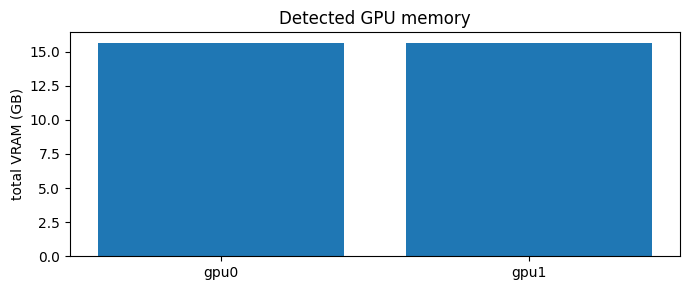

18:52:30 | INFO | saved figs/gpu_memory.png


In [4]:
import subprocess
logger.info('hardware and GPU optimisation')
if shutil.which('nvidia-smi') is not None:
    try:
        out = subprocess.run(['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free,driver_version', '--format=csv'], capture_output=True, text=True, timeout=30)
        logger.info('nvidia-smi output captured')
        print(out.stdout.strip()[:2000])
    except Exception as e:
        logger.warning('nvidia-smi failed: %s', e)
else:
    logger.warning('nvidia-smi not found')
if torch.cuda.is_available():
    for i in tqdm(range(torch.cuda.device_count()), desc='gpu-info'):
        p = torch.cuda.get_device_properties(i)
        logger.info('gpu %d: %s total %.1f GB mp %d', i, p.name, p.total_memory / 1e9, p.multi_processor_count)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        logger.info('TF32 allowed')
    except Exception as e:
        logger.warning('TF32 skipped: %s', e)
    try:
        torch.set_float32_matmul_precision('high')
        logger.info('matmul precision high')
    except Exception as e:
        logger.warning('matmul precision skipped: %s', e)
    torch.set_num_threads(os.cpu_count() or 4)
    logger.info('torch threads %d', torch.get_num_threads())
else:
    logger.warning('no CUDA device. Enable GPU T4 x 2 for full speed.')
amp_ok = torch.cuda.is_available()
compile_ok = hasattr(torch, 'compile') and (NGPUS < 2)
logger.info('amp %s compile %s channels_last %s dataparallel %s', amp_ok and cfg.use_amp, compile_ok and cfg.use_compile, cfg.use_channels_last, 'yes' if NGPUS >= 2 else 'no')
hw_df = pd.DataFrame([{'check': 'GPUs', 'value': NGPUS}, {'check': 'AMP FP16', 'value': 'on' if (amp_ok and cfg.use_amp) else 'off'}, {'check': 'cuDNN benchmark', 'value': 'on'}, {'check': 'TF32', 'value': 'allowed'}, {'check': 'channels-last', 'value': str(cfg.use_channels_last)}, {'check': 'torch.compile', 'value': str(compile_ok and cfg.use_compile) if NGPUS < 2 else 'off (DataParallel active)'}, {'check': 'DataParallel', 'value': 'yes' if NGPUS >= 2 else 'no'}, {'check': 'workers', 'value': NWORKERS}])
print(hw_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 3))
if torch.cuda.is_available():
    mems = [torch.cuda.get_device_properties(i).total_memory / 1e9 for i in range(torch.cuda.device_count())]
    ax.bar(['gpu' + str(i) for i in range(len(mems))], mems)
    ax.set_ylabel('total VRAM (GB)')
    ax.set_title('Detected GPU memory')
else:
    ax.text(0.5, 0.5, 'no CUDA device', ha='center')
    ax.set_title('Detected GPU memory')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'gpu_memory.png'), dpi=150)
plt.show()
logger.info('saved figs/gpu_memory.png')

18:52:30 | INFO | dataset discovery under /kaggle/input only


scan-input:   0%|          | 0/646997 [00:00<?, ?it/s]

19:25:41 | INFO | found 539147 images (incl. .ppm for FlyingChairs)
19:25:42 | INFO | held-out (Vid4/SR-benchmarks, excluded from training): 1857
19:25:42 | INFO | training pool: 537290
 dataset  images  share_pct
datasets  537290      100.0
19:26:07 | INFO | per-dataset table logged


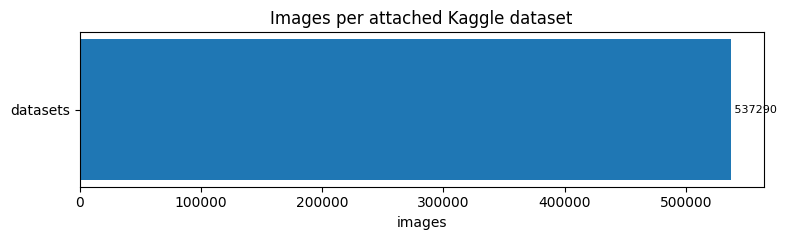

held-out inventory (eval only):
dataset
datasets    1857
19:26:07 | INFO | saved outputs/discovery.csv


In [5]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff', '.ppm', '.pgm', '.gif'}
HOLDOUT_HINTS = ('vid4', 'super-resolution-benchmark')  # RESEARCH 3.6: never train on these
logger.info('dataset discovery under /kaggle/input only')
if not INPUT_ROOT.exists():
    raise RuntimeError('Kaggle-only notebook: /kaggle/input missing.')
img_files = []
for root, _, files in os.walk(str(INPUT_ROOT)):
    if any(part.startswith('.') for part in Path(root).parts):
        continue
    for f in files:
        if f.startswith('.'):
            continue
        ext = os.path.splitext(f)[1].lower()
        if ext in IMG_EXTS:
            img_files.append(Path(root) / f)
img_files = sorted(img_files)
logger.info('found %d images (incl. .ppm for FlyingChairs)', len(img_files))
holdout_files = [p for p in img_files if any(h in str(p).lower() for h in HOLDOUT_HINTS)]
holdout_set = set(holdout_files)
train_pool = [p for p in img_files if p not in holdout_set]
logger.info('held-out (Vid4/SR-benchmarks, excluded from training): %d', len(holdout_files))
logger.info('training pool: %d', len(train_pool))
if len(train_pool) == 0:
    raise RuntimeError('Only held-out datasets attached. Attach a training set (e.g. soumikrakshit/div2k-high-resolution-images).')
if len(img_files) == 0:
    raise RuntimeError('No images under /kaggle/input. Attach a dataset with + Add Input.')
KNOWN_DATASETS = [
    'div2k-high-resolution-images', 'flickr2k', 'df2k-ost', 'realsr-v3',
    'reds-video-superresolution-toy-dataset', 'reds-dataset', 'mpi-sintel-dataset',
    'vimeo-90k-7', 'vimeo-triplet', 'flyingchairs', 'vid4-dataset',
    'super-resolution-benchmarks',
]
def top_ds(p):
    try:
        rel = p.relative_to(INPUT_ROOT)
        for part in rel.parts:
            low = part.lower()
            for kd in KNOWN_DATASETS:
                if kd in low:
                    return kd
        parts = rel.parts
        if parts[0].lower() in ('datasets', 'data', 'input') and len(parts) > 2:
            return parts[1]
        return parts[0] if len(parts) > 1 else 'root'
    except Exception:
        return 'root'
counts = Counter([top_ds(p) for p in train_pool])
ds_df = pd.DataFrame([{'dataset': k, 'images': int(v)} for k, v in counts.most_common()])
ds_df['share_pct'] = (100.0 * ds_df['images'] / max(1, len(train_pool))).round(2)
print(ds_df.to_string(index=False))
logger.info('per-dataset table logged')
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(ds_df))))
ax.barh(ds_df['dataset'], ds_df['images'])
ax.set_xlabel('images')
ax.set_title('Images per attached Kaggle dataset')
for i, v in enumerate(ds_df['images']):
    ax.text(v, i, ' ' + str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'dataset_counts.png'), dpi=150)
plt.show()
ds_df.to_csv(str(OUT_DIR / 'discovery.csv'), index=False)
hold_df = pd.DataFrame([{'dataset': top_ds(p), 'images': 1} for p in holdout_files])
if len(hold_df):
    print('held-out inventory (eval only):')
    print(hold_df.groupby('dataset').size().to_string())
logger.info('saved outputs/discovery.csv')

19:26:07 | INFO | EDA: resolution, mode, mean and std


eda-sizes:   0%|          | 0/800 [00:00<?, ?it/s]

             W        H      mp  aspect
count   800.00   800.00  800.00  800.00
mean    448.89   282.79    0.19    1.59
std     309.04   216.61    0.40    0.45
min      32.00    32.00    0.00    0.37
25%     320.00   215.25    0.06    1.33
50%     448.00   256.00    0.11    1.75
75%     448.00   256.00    0.11    1.75
max    2040.00  2040.00    4.16    5.71
mode
RGB    797
L        3
19:26:17 | INFO | eda n 800 median 448x256


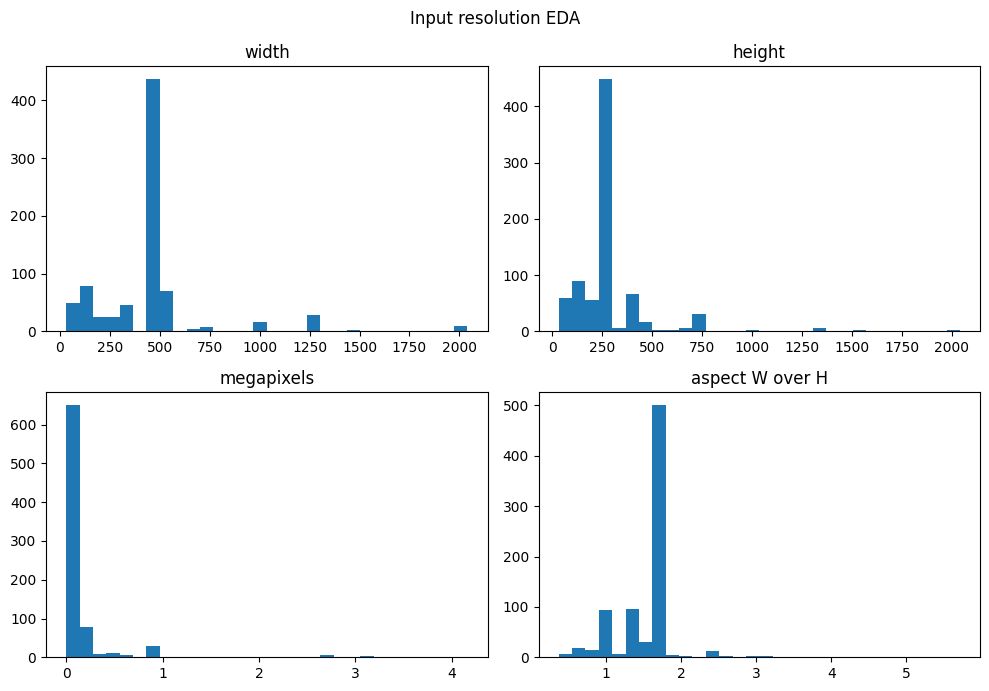

eda-meanstd:   0%|          | 0/256 [00:00<?, ?it/s]

channel   mean    std
      R 0.3949 0.2625
      G 0.3860 0.2529
      B 0.3612 0.2621
19:26:22 | INFO | rgb stats logged


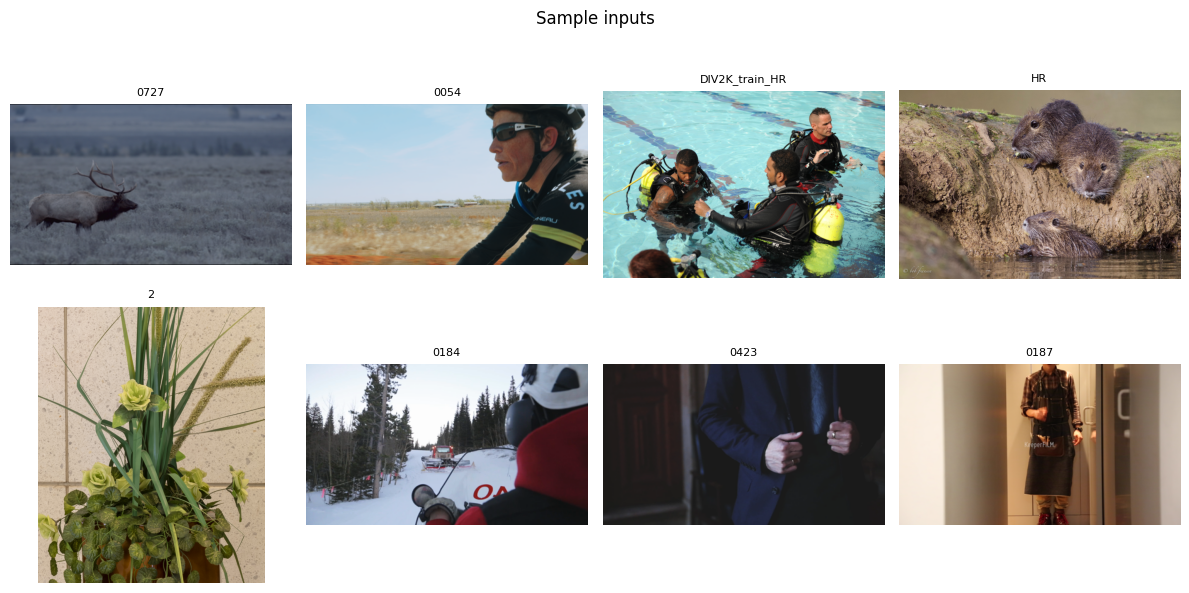

19:26:25 | INFO | saved eda figures and csv


In [6]:
logger.info('EDA: resolution, mode, mean and std')
NS = min(800, len(img_files))
rng = random.Random(SEED)
eda_sample = rng.sample(img_files, NS)
rows = []
for p in tqdm(eda_sample, desc='eda-sizes'):
    try:
        with Image.open(p) as im:
            im.load()
            rows.append([p.name, im.size[0], im.size[1], im.mode])
    except Exception as e:
        logger.warning('skip corrupt file: %s', e)
edadf = pd.DataFrame(rows, columns=['file', 'W', 'H', 'mode'])
edadf['mp'] = edadf['W'] * edadf['H'] / 1e6
edadf['aspect'] = edadf['W'] / edadf['H'].clip(lower=1)
print(edadf[['W', 'H', 'mp', 'aspect']].describe().round(2).to_string())
print(edadf['mode'].value_counts().head(10).to_string())
logger.info('eda n %d median %dx%d', len(edadf), int(edadf['W'].median()), int(edadf['H'].median()))
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].hist(edadf['W'], bins=30)
axes[0, 0].set_title('width')
axes[0, 1].hist(edadf['H'], bins=30)
axes[0, 1].set_title('height')
axes[1, 0].hist(edadf['mp'], bins=30)
axes[1, 0].set_title('megapixels')
axes[1, 1].hist(edadf['aspect'], bins=30)
axes[1, 1].set_title('aspect W over H')
plt.suptitle('Input resolution EDA')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'eda_resolution.png'), dpi=150)
plt.show()
NM = min(256, len(img_files))
mean_sample = rng.sample(img_files, NM)
sum_c = np.zeros(3, dtype=np.float64)
sumsq_c = np.zeros(3, dtype=np.float64)
npix = 0
for p in tqdm(mean_sample, desc='eda-meanstd'):
    try:
        with Image.open(p) as im:
            a = np.asarray(im.convert('RGB').resize((128, 128)), dtype=np.float64) / 255.0
            sum_c = sum_c + a.sum(axis=(0, 1))
            sumsq_c = sumsq_c + (a ** 2).sum(axis=(0, 1))
            npix = npix + a.shape[0] * a.shape[1]
    except Exception:
        continue
mean = sum_c / max(1, npix)
std = np.sqrt(np.maximum(0, sumsq_c / max(1, npix) - mean ** 2))
stat_df = pd.DataFrame([{'channel': c, 'mean': round(float(mean[i]), 4), 'std': round(float(std[i]), 4)} for i, c in enumerate(['R', 'G', 'B'])])
print(stat_df.to_string(index=False))
logger.info('rgb stats logged')
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
vis8 = rng.sample(img_files, min(8, len(img_files)))
for ax, p in zip(axes.flat, vis8):
    try:
        with Image.open(p) as im:
            ax.imshow(np.asarray(im.convert('RGB')))
            ax.set_title(p.parent.name[:18], fontsize=8)
            ax.axis('off')
    except Exception:
        ax.axis('off')
plt.suptitle('Sample inputs')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'eda_samples.png'), dpi=150)
plt.show()
edadf.to_csv(str(OUT_DIR / 'eda_stats.csv'), index=False)
logger.info('saved eda figures and csv')

19:26:25 | INFO | paired data loading at scale 3
19:26:26 | INFO | sequence groups: 83639 (train 66913 dirs, val 8363, test 8363)
split  images
train  446982
  val     400
 test     400
19:26:26 | INFO | split done
19:26:26 | INFO | train batches 6984 val 7 test 7
19:26:28 | INFO | batch shapes ready


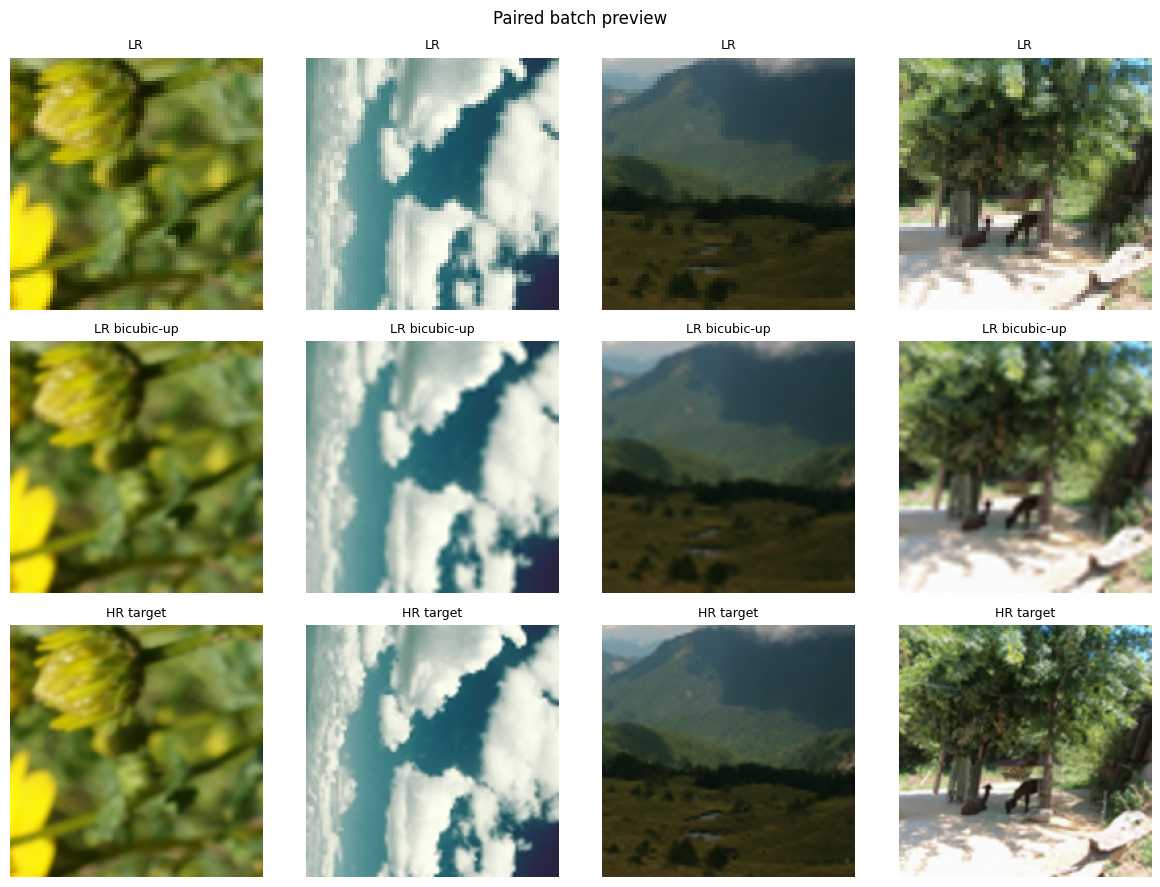

loader-benchmark:   0%|          | 0/30 [00:00<?, ?it/s]

19:26:42 | INFO | loader 30 batches in 11.30 s: 169.9 img per s
      metric  value
   img_per_s  169.9
ms_per_batch  376.7


In [7]:
import torch.nn.functional as F
import torchvision.transforms.functional as TF
def safe_down(hr_t, scale):
    try:
        return F.interpolate(hr_t.unsqueeze(0), scale_factor=1.0 / scale, mode='bicubic', align_corners=False, antialias=True).squeeze(0).clamp(0, 1)
    except TypeError:  # older torch without antialias kwarg
        return F.interpolate(hr_t.unsqueeze(0), scale_factor=1.0 / scale, mode='bicubic', align_corners=False).squeeze(0).clamp(0, 1)
logger.info('paired data loading at scale %d', cfg.scale)
class PairedSRDataset(torch.utils.data.Dataset):
    '''HR from Kaggle input only. LR made on the fly by bicubic downsampling.'''
    def __init__(self, files, scale=3, hr_patch=192, is_train=True, seed=42):
        self.files = list(files)
        self.scale = scale
        self.hr_patch = hr_patch
        self.is_train = is_train
        self.rng = random.Random(seed + (0 if is_train else 9999))
    def __len__(self):
        return len(self.files)
    def _open(self, idx):
        for k in range(5):
            try:
                p = self.files[(idx + k) % len(self.files)]
                with Image.open(p) as im:
                    im.load()
                    return im.convert('RGB')
            except Exception:
                continue
        raise RuntimeError('too many corrupt images')
    def __getitem__(self, idx):
        im = self._open(idx)
        w, h = im.size
        if self.is_train:
            if w < self.hr_patch or h < self.hr_patch:
                scale_up = max(self.hr_patch / max(1, w), self.hr_patch / max(1, h))
                new_w = max(self.hr_patch, int(math.ceil(w * scale_up)))
                new_h = max(self.hr_patch, int(math.ceil(h * scale_up)))
                im = im.resize((new_w, new_h), Image.BICUBIC)
                w, h = im.size
            hp = min(self.hr_patch, w - (w % self.scale), h - (h % self.scale))
            hp = max(hp, self.scale * 16)
            hp = hp - (hp % self.scale)
            x = self.rng.randint(0, max(0, w - hp))
            y = self.rng.randint(0, max(0, h - hp))
            hr = im.crop((x, y, x + hp, y + hp))
            if self.rng.random() < 0.5:
                hr = hr.transpose(Image.FLIP_LEFT_RIGHT)
            if self.rng.random() < 0.25:
                hr = hr.transpose(Image.FLIP_TOP_BOTTOM)
            if self.rng.random() < 0.25:
                hr = hr.rotate(90, expand=True)
            if hr.size[0] != self.hr_patch or hr.size[1] != self.hr_patch:
                hr = hr.resize((self.hr_patch, self.hr_patch), Image.BICUBIC)
            if self.rng.random() < 0.2:
                b = 0.9 + 0.2 * self.rng.random()
                arr = np.asarray(hr).astype(np.float32) * b
                hr = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
        else:
            s = min(w, h, 384)
            x = (w - s) // 2
            y = (h - s) // 2
            hr = im.crop((x, y, x + s, y + s))
            s = s - (s % self.scale)
            hr = hr.resize((s, s), Image.BICUBIC)
        hr_t = TF.to_tensor(hr)
        return safe_down(hr_t, self.scale), hr_t
# Sequence-aware split: keep frames from one folder in one split (no video leakage).
pool = list(train_pool) if 'train_pool' in dir() else list(img_files)
groups = {}
for p in pool:
    try:
        groups.setdefault(str(p.parent), []).append(p)
    except Exception:
        groups.setdefault('root', []).append(p)
gkeys = sorted(groups.keys())
random.Random(SEED).shuffle(gkeys)
n_val_g = max(1, int(0.10 * len(gkeys)))
n_test_g = max(1, int(0.10 * len(gkeys)))
if len(gkeys) < 10:
    n_val_g = max(1, len(gkeys) // 5)
    n_test_g = max(1, len(gkeys) // 5)
train_files, val_files, test_files = [], [], []
for g in gkeys[:len(gkeys) - n_val_g - n_test_g]:
    train_files += groups[g]
for g in gkeys[len(gkeys) - n_val_g - n_test_g:len(gkeys) - n_test_g]:
    val_files += groups[g]
for g in gkeys[len(gkeys) - n_test_g:]:
    test_files += groups[g]
random.Random(SEED).shuffle(train_files)
random.Random(SEED + 1).shuffle(val_files)
if cfg.limit_train is not None:
    train_files = train_files[:int(cfg.limit_train)]
val_files = val_files[:int(cfg.limit_val)]
test_files = test_files[:int(cfg.limit_val)]
logger.info('sequence groups: %d (train %d dirs, val %d, test %d)', len(gkeys), len(gkeys) - n_val_g - n_test_g, n_val_g, n_test_g)
split_df = pd.DataFrame([{'split': 'train', 'images': len(train_files)}, {'split': 'val', 'images': len(val_files)}, {'split': 'test', 'images': len(test_files)}])
print(split_df.to_string(index=False))
logger.info('split done')
train_ds = PairedSRDataset(train_files, scale=cfg.scale, hr_patch=cfg.hr_patch, is_train=True, seed=SEED)
val_ds = PairedSRDataset(val_files, scale=cfg.scale, hr_patch=cfg.hr_patch, is_train=False, seed=SEED)
test_ds = PairedSRDataset(test_files, scale=cfg.scale, hr_patch=cfg.hr_patch, is_train=False, seed=SEED)
def worker_init_fn(worker_id):
    worker_seed = (torch.initial_seed() + worker_id) % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

loader_kw = {'num_workers': NWORKERS, 'pin_memory': True, 'drop_last': True, 'worker_init_fn': worker_init_fn} if NWORKERS > 0 else {'num_workers': 0, 'pin_memory': False, 'drop_last': True}
if NWORKERS > 0:
    loader_kw['persistent_workers'] = True
    loader_kw['prefetch_factor'] = 4
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg.batch_per_gpu * max(1, NGPUS), shuffle=True, **loader_kw)
val_kw = dict(loader_kw)
val_kw['drop_last'] = False
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=cfg.batch_per_gpu * max(1, NGPUS), shuffle=False, **val_kw)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=cfg.batch_per_gpu * max(1, NGPUS), shuffle=False, **val_kw)
logger.info('train batches %d val %d test %d', len(train_loader), len(val_loader), len(test_loader))
lr_b, hr_b = next(iter(train_loader))
logger.info('batch shapes ready')
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(min(4, lr_b.shape[0])):
    lr = lr_b[i].permute(1, 2, 0).numpy()
    hr = hr_b[i].permute(1, 2, 0).numpy()
    up = np.asarray(Image.fromarray((lr * 255).astype(np.uint8)).resize((hr.shape[1], hr.shape[0]), Image.BICUBIC)) / 255.0
    axes[0, i].imshow(lr)
    axes[0, i].set_title('LR', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(up)
    axes[1, i].set_title('LR bicubic-up', fontsize=9)
    axes[1, i].axis('off')
    axes[2, i].imshow(hr)
    axes[2, i].set_title('HR target', fontsize=9)
    axes[2, i].axis('off')
plt.suptitle('Paired batch preview')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'batch_preview.png'), dpi=150)
plt.show()
t0 = time.time()
NB = min(30, len(train_loader))
it = iter(train_loader)
for _ in tqdm(range(NB), desc='loader-benchmark'):
    try:
        b = next(it)
    except StopIteration:
        break
dt = time.time() - t0
ips = (NB * lr_b.shape[0]) / max(1e-6, dt)
logger.info('loader %d batches in %.2f s: %.1f img per s', NB, dt, ips)
print(pd.DataFrame([{'metric': 'img_per_s', 'value': round(ips, 1)}, {'metric': 'ms_per_batch', 'value': round(1000.0 * dt / max(1, NB), 1)}]).to_string(index=False))

In [ ]:
import torch.nn as nn
logger.info('model: reparameterisable trunk, RGB adaptation')
class ReparamBlock(nn.Module):
    '''Multi-branch training block. Fuses to one 3x3 conv.'''
    def __init__(self, c):
        super().__init__()
        self.c = c
        self.conv3 = nn.Conv2d(c, c, 3, padding=1, bias=True)
        self.conv1 = nn.Conv2d(c, c, 1, padding=0, bias=True)
        sx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        sy = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
        lp = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]]).view(1, 1, 3, 3)
        self.register_buffer('kx', sx)
        self.register_buffer('ky', sy)
        self.register_buffer('kl', lp)
        self.cx = nn.Conv2d(c, c, 1, bias=True)
        self.cy = nn.Conv2d(c, c, 1, bias=True)
        self.cl = nn.Conv2d(c, c, 1, bias=True)
        self.act = nn.PReLU(num_parameters=c)
    def forward(self, x):
        o = self.conv3(x) + self.conv1(x)
        fx = F.conv2d(x, self.kx.repeat(self.c, 1, 1, 1), padding=1, groups=self.c)
        fy = F.conv2d(x, self.ky.repeat(self.c, 1, 1, 1), padding=1, groups=self.c)
        fl = F.conv2d(x, self.kl.repeat(self.c, 1, 1, 1), padding=1, groups=self.c)
        o = o + self.cx(fx) + self.cy(fy) + self.cl(fl) + x
        return self.act(o)
    @torch.no_grad()
    def fused(self):
        w = self.conv3.weight.clone()
        b = self.conv3.bias.clone()
        w = w + F.pad(self.conv1.weight, (1, 1, 1, 1))
        b = b + self.conv1.bias
        w = w + self.cx.weight * self.kx + self.cy.weight * self.ky + self.cl.weight * self.kl
        b = b + self.cx.bias + self.cy.bias + self.cl.bias
        eye = torch.zeros_like(w)
        for i in range(self.c):
            eye[i, i, 1, 1] = 1.0
        w = w + eye
        return w, b
class RepTNSR(nn.Module):
    '''RGB input for Kaggle. G-buffer build uses in_ch 12 with same trunk.'''
    def __init__(self, in_ch=3, base=24, num_blocks=6, scale=3):
        super().__init__()
        self.scale = scale
        self.base = base
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1, bias=True)
        self.in_act = nn.PReLU(num_parameters=base)
        self.blocks = nn.ModuleList([ReparamBlock(base) for _ in range(num_blocks)])
        self.out_conv = nn.Conv2d(base, 3 * (scale ** 2), 3, padding=1, bias=True)
        self.shuffle = nn.PixelShuffle(scale)
    def forward(self, x):
        f = self.in_act(self.in_conv(x))
        for blk in self.blocks:
            f = blk(f)
        return self.shuffle(self.out_conv(f))
def count_params(m):
    return sum(p.numel() for p in m.parameters())
def est_gmacs(base, blocks, scale, h=360, w=640, in_ch=3):
    n = h * w
    macs = n * (in_ch * base * 9 + blocks * base * base * 9 + base * 3 * (scale ** 2) * 9)
    return macs / 1e9
spec = TIERS[cfg.tier]
model = RepTNSR(in_ch=3, base=spec['base_channels'], num_blocks=spec['num_blocks'], scale=cfg.scale)
logger.info('tier %s params %d gmacs %.2f', cfg.tier, count_params(model), est_gmacs(spec['base_channels'], spec['num_blocks'], cfg.scale))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
if cfg.use_channels_last and device.type == 'cuda':
    model = model.to(memory_format=torch.channels_last)
    logger.info('channels-last on')
if NGPUS >= 2:
    model = nn.DataParallel(model)
    logger.info('DataParallel over %d GPUs (torch.compile disabled for multi-GPU DP stability)', NGPUS)
elif cfg.use_compile and hasattr(torch, 'compile') and device.type == 'cuda':
    try:
        model = torch.compile(model, mode='default')
        logger.info('torch.compile on (single-GPU mode)')
    except Exception as e:
        logger.warning('compile skipped: %s', e)
model.train()
with torch.no_grad():
    d = torch.randn(2, 3, LR_PATCH, LR_PATCH, device=device)
    if cfg.use_channels_last and device.type == 'cuda':
        d = d.to(memory_format=torch.channels_last)
    y = model(d)
    logger.info('forward check passed')
    assert y.shape[2] == LR_PATCH * cfg.scale
tier_rows = []
for name, s in TIERS.items():
    m0 = RepTNSR(in_ch=3, base=s['base_channels'], num_blocks=s['num_blocks'], scale=cfg.scale)
    tier_rows.append({'tier': name, 'blocks': s['num_blocks'], 'channels': s['base_channels'], 'params': count_params(m0), 'gmacs_360p': round(est_gmacs(s['base_channels'], s['num_blocks'], cfg.scale), 2)})
tier_df = pd.DataFrame(tier_rows)
print(tier_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(tier_df['tier'], tier_df['params'])
ax.set_ylabel('parameters')
ax.set_title('Model size by tier, 50K budget line')
ax.axhline(50000, linestyle='--')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'model_tiers.png'), dpi=150)
plt.show()

In [ ]:
logger.info('losses and metrics from scratch, offline safe')
KX = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
KY = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
class Charbonnier(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps
    def forward(self, a, b):
        return torch.sqrt((a - b) ** 2 + self.eps ** 2).mean()
def rgb_to_y(x):
    return 0.25 * x[:, 0:1] + 0.5 * x[:, 1:2] + 0.25 * x[:, 2:3]
def edge_loss(a, b):
    w = a.shape[1]
    kx = KX.repeat(w, 1, 1, 1).to(a.device).type_as(a)
    ky = KY.repeat(w, 1, 1, 1).to(a.device).type_as(a)
    ax = F.conv2d(a, kx, padding=1, groups=w)
    ay = F.conv2d(a, ky, padding=1, groups=w)
    bx = F.conv2d(b, kx, padding=1, groups=w)
    by = F.conv2d(b, ky, padding=1, groups=w)
    return (ax - bx).abs().mean() + (ay - by).abs().mean()
def freq_loss(a, b):
    fa = torch.fft.fft2(rgb_to_y(a))
    fb = torch.fft.fft2(rgb_to_y(b))
    n = a.shape[2] * a.shape[3]
    return (fa - fb).abs().mean() / max(1, n) * 100.0
class SRLoss(nn.Module):
    def __init__(self, w_char=1.0, w_edge=0.5, w_freq=0.1):
        super().__init__()
        self.char = Charbonnier()
        self.w_char = w_char
        self.w_edge = w_edge
        self.w_freq = w_freq
    def forward(self, sr, hr):
        lc = self.char(sr, hr)
        le = edge_loss(sr, hr)
        lf = freq_loss(sr, hr)
        total = self.w_char * lc + self.w_edge * le + self.w_freq * lf
        return total, {'char': float(lc.detach()), 'edge': float(le.detach()), 'freq': float(lf.detach())}
def psnr_batch(a, b):
    mse = ((a - b) ** 2).mean(dim=(1, 2, 3))
    return 10 * torch.log10(1.0 / (mse + 1e-8))
def _gauss(ch, win=11, sigma=1.5):
    c = torch.arange(win).float() - win // 2
    g = torch.exp(-(c ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w = g[:, None] * g[None, :]
    return w.expand(ch, 1, win, win).contiguous()
def ssim_batch(a, b, win=11):
    ch = a.shape[1]
    w = _gauss(ch, win).to(a.device).type_as(a)
    pad = win // 2
    m1 = F.conv2d(a, w, padding=pad, groups=ch)
    m2 = F.conv2d(b, w, padding=pad, groups=ch)
    s1 = m1 * m1
    s2 = m2 * m2
    m12 = m1 * m2
    v1 = F.conv2d(a * a, w, padding=pad, groups=ch) - s1
    v2 = F.conv2d(b * b, w, padding=pad, groups=ch) - s2
    v12 = F.conv2d(a * b, w, padding=pad, groups=ch) - m12
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    m = (2 * m12 + c1) * (2 * v12 + c2) / ((s1 + s2 + c1) * (v1 + v2 + c2) + 1e-8)
    return m.mean(dim=(1, 2, 3))
criterion = SRLoss(w_char=1.0, w_edge=0.5, w_freq=0.1)
logger.info('loss weights char 1.0 edge 0.5 freq 0.1')
with torch.no_grad():
    ta = torch.rand(4, 3, 64, 64)
    tb = torch.rand(4, 3, 64, 64)
    tot, parts = criterion(ta, tb)
    ps = psnr_batch(ta, tb).mean().item()
    ss = ssim_batch(ta, tb).mean().item()
    check_df = pd.DataFrame([{'metric': 'charbonnier', 'value': round(parts['char'], 5)}, {'metric': 'edge', 'value': round(parts['edge'], 5)}, {'metric': 'freq', 'value': round(parts['freq'], 5)}, {'metric': 'total', 'value': round(float(tot), 5)}, {'metric': 'psnr_random', 'value': round(ps, 2)}, {'metric': 'ssim_random', 'value': round(ss, 4)}])
    print(check_df.to_string(index=False))
    logger.info('loss sanity check passed')

In [ ]:
logger.info('optimiser, scheduler, AMP, EMA, checkpoints')
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.999), weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=1e-6)
USE_AMP = bool(device.type == 'cuda' and cfg.use_amp)
scaler = None
if USE_AMP:
    try:
        scaler = torch.amp.GradScaler('cuda')
        logger.info('GradScaler on')
    except Exception as e:
        logger.warning('scaler fallback: %s', e)
        scaler = torch.cuda.amp.GradScaler()
else:
    logger.info('AMP off, fp32 training')
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n] = p.detach().clone()
    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.detach(), alpha=1.0 - self.decay)
    @torch.no_grad()
    def copy_to(self, model):
        bak = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                bak[n] = p.detach().clone()
                p.copy_(self.shadow[n])
        return bak
    @torch.no_grad()
    def restore(self, model, bak):
        for n, p in model.named_parameters():
            if n in bak:
                p.copy_(bak[n])
    def state_dict(self):
        return {'decay': self.decay, 'shadow': self.shadow}
    def load_state_dict(self, sd):
        self.decay = sd.get('decay', 0.999)
        self.shadow = sd['shadow']
ema = EMA(model, decay=0.999)
logger.info('EMA decay 0.999')
def save_ckpt(path, model, opt, sch, scl, ema_o, epoch, step, best):
    raw_m = model.module if isinstance(model, nn.DataParallel) else model
    d = {'epoch': epoch, 'step': step, 'best_psnr': best, 'model': raw_m.state_dict(), 'optim': opt.state_dict(), 'sched': sch.state_dict(), 'ema': ema_o.state_dict(), 'cfg': asdict(cfg)}
    if scl is not None:
        d['scaler'] = scl.state_dict()
    d['rng'] = {'torch': torch.get_rng_state(), 'numpy': np.random.get_state(), 'python': random.getstate()}
    torch.save(d, path)
    logger.info('saved %s epoch %d best %.2f', path, epoch, best)
def load_ckpt(path, model, opt, sch, scl, ema_o):
    ck = torch.load(path, map_location=device)
    raw_m = model.module if isinstance(model, nn.DataParallel) else model
    sd = {}
    for k, v in ck['model'].items():
        key = k
        while key.startswith(('module.', '_orig_mod.')):
            key = key.split('.', 1)[1]
        sd[key] = v
    raw_m.load_state_dict(sd)
    opt.load_state_dict(ck['optim'])
    sch.load_state_dict(ck['sched'])
    if scl is not None and 'scaler' in ck and ck['scaler'] is not None:
        scl.load_state_dict(ck['scaler'])
    if 'ema' in ck:
        ema_o.load_state_dict(ck['ema'])
    logger.info('resumed %s epoch %d best %.2f', path, ck['epoch'], ck['best_psnr'])
    return ck['epoch'], ck['step'], ck['best_psnr']
start_epoch, gstep, best_psnr = 0, 0, -1.0
LAST_CKPT = CKPT_DIR / 'last.pt'
BEST_CKPT = CKPT_DIR / 'best.pt'
if LAST_CKPT.exists():
    try:
        start_epoch, gstep, best_psnr = load_ckpt(str(LAST_CKPT), model, optimizer, scheduler, scaler, ema)
        start_epoch = start_epoch + 1
    except Exception as e:
        logger.warning('resume failed, fresh start: %s', e)
print(pd.DataFrame([{'item': 'lr', 'value': cfg.lr}, {'item': 'weight_decay', 'value': cfg.weight_decay}, {'item': 'scheduler', 'value': 'cosine'}, {'item': 'amp', 'value': str(USE_AMP)}, {'item': 'start_epoch', 'value': start_epoch}, {'item': 'best_psnr', 'value': round(best_psnr, 2)}]).to_string(index=False))

In [ ]:
logger.info('training with AMP, accumulation, checkpointing')
HIST_CSV = OUT_DIR / 'history.csv'
T_START = time.time()
BUDGET_S = cfg.max_hours * 3600.0
def run_validate(loader, use_ema=True):
    was_train = model.training
    model.eval()
    bak = ema.copy_to(model) if use_ema else None
    tot, n, ps, ss = 0.0, 0, 0.0, 0.0
    with torch.no_grad():
        for lr, hr in tqdm(loader, desc='validate', leave=False):
            lr = lr.to(device, non_blocking=True)
            hr = hr.to(device, non_blocking=True)
            if cfg.use_channels_last and device.type == 'cuda':
                lr = lr.to(memory_format=torch.channels_last)
            if USE_AMP:
                try:
                    with torch.amp.autocast('cuda', dtype=torch.float16):
                        sr = model(lr)
                except Exception:
                    with torch.cuda.amp.autocast():
                        sr = model(lr)
            else:
                sr = model(lr)
            sr = sr.clamp(0, 1)
            loss, _ = criterion(sr, hr)
            tot = tot + float(loss) * lr.shape[0]
            ps = ps + float(psnr_batch(sr, hr).mean()) * lr.shape[0]
            ss = ss + float(ssim_batch(sr, hr).mean()) * lr.shape[0]
            n = n + lr.shape[0]
    if use_ema:
        ema.restore(model, bak)
    if was_train:
        model.train()
    return tot / max(1, n), ps / max(1, n), ss / max(1, n)
history = []
if HIST_CSV.exists() and start_epoch > 0:
    try:
        history = pd.read_csv(str(HIST_CSV)).to_dict(orient='records')
        logger.info('loaded history rows %d', len(history))
    except Exception:
        history = []
for epoch in tqdm(range(start_epoch, cfg.epochs), desc='epochs'):
    if time.time() - T_START > BUDGET_S - 600:
        logger.warning('time budget guard: stopping to allow packaging')
        break
    model.train()
    run_loss, run_psnr, seen = 0.0, 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(train_loader, desc='train e%d' % epoch, leave=False)
    for bi, (lr, hr) in enumerate(pbar):
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)
        if cfg.use_channels_last and device.type == 'cuda':
            lr = lr.to(memory_format=torch.channels_last)
        if USE_AMP:
            try:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    sr = model(lr)
                    loss_raw, _ = criterion(sr, hr)
                    loss = loss_raw / cfg.accum_steps
            except Exception:
                with torch.cuda.amp.autocast():
                    sr = model(lr)
                    loss_raw, _ = criterion(sr, hr)
                    loss = loss_raw / cfg.accum_steps
            scaler.scale(loss).backward()
            if (bi + 1) % cfg.accum_steps == 0 or (bi + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)
        else:
            sr = model(lr)
            loss_raw, _ = criterion(sr, hr)
            loss = loss_raw / cfg.accum_steps
            loss.backward()
            if (bi + 1) % cfg.accum_steps == 0 or (bi + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)
        gstep = gstep + 1
        with torch.no_grad():
            b_psnr = float(psnr_batch(sr.detach().clamp(0, 1), hr).mean())
        run_loss = run_loss + float(loss_raw.detach())
        run_psnr = run_psnr + b_psnr
        seen = seen + 1
        pbar.set_postfix({'loss': '%.4f' % (run_loss / seen), 'psnr': '%.2f' % (run_psnr / seen), 'lr': '%.2e' % optimizer.param_groups[0]['lr']})
    scheduler.step()
    tr_loss = run_loss / max(1, seen)
    tr_psnr = run_psnr / max(1, seen)
    if (epoch + 1) % cfg.val_interval == 0:
        va_loss, va_psnr, va_ssim = run_validate(val_loader, use_ema=True)
    else:
        va_loss, va_psnr, va_ssim = float('nan'), float('nan'), float('nan')
    row = {'epoch': epoch, 'train_loss': round(tr_loss, 5), 'train_psnr': round(tr_psnr, 3), 'val_loss': round(float(va_loss), 5), 'val_psnr': round(float(va_psnr), 3), 'val_ssim': round(float(va_ssim), 5), 'lr': optimizer.param_groups[0]['lr'], 'best': round(best_psnr, 3)}
    history.append(row)
    pd.DataFrame(history).to_csv(str(HIST_CSV), index=False)
    logger.info('epoch %d train %.4f psnr %.2f val %.4f psnr %.2f ssim %.4f', epoch, tr_loss, tr_psnr, va_loss, va_psnr, va_ssim)
    save_ckpt(str(LAST_CKPT), model, optimizer, scheduler, scaler, ema, epoch, gstep, best_psnr)
    if va_psnr == va_psnr and va_psnr > best_psnr:
        best_psnr = float(va_psnr)
        save_ckpt(str(BEST_CKPT), model, optimizer, scheduler, scaler, ema, epoch, gstep, best_psnr)
        logger.info('new best %.3f', best_psnr)
    ep_ckpt = CKPT_DIR / ('epoch_%03d.pt' % epoch)
    save_ckpt(str(ep_ckpt), model, optimizer, scheduler, scaler, ema, epoch, gstep, best_psnr)
    olds = sorted(CKPT_DIR.glob('epoch_*.pt'))
    for old in olds[:-cfg.keep_last_k]:
        try:
            old.unlink()
        except Exception:
            pass
print(pd.DataFrame(history).to_string(index=False))
logger.info('training done. best val psnr %.3f', best_psnr)

In [ ]:
logger.info('training history plots and table')
hist_df = pd.read_csv(str(HIST_CSV))
print(hist_df.to_string(index=False))
valid_val = hist_df.dropna(subset=['val_psnr'])
best_row = valid_val.loc[valid_val['val_psnr'].idxmax()] if len(valid_val) else hist_df.iloc[-1]
logger.info('best epoch %d val psnr %.3f ssim %.5f', int(best_row['epoch']), float(best_row['val_psnr']), float(best_row['val_ssim']))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(hist_df['epoch'], hist_df['train_loss'], marker='o', label='train')
axes[0, 0].plot(hist_df['epoch'], hist_df['val_loss'], marker='o', label='val')
axes[0, 0].set_title('loss')
axes[0, 0].legend()
axes[0, 1].plot(hist_df['epoch'], hist_df['train_psnr'], marker='o', label='train')
axes[0, 1].plot(hist_df['epoch'], hist_df['val_psnr'], marker='o', label='val')
axes[0, 1].set_title('PSNR dB, higher better')
axes[0, 1].legend()
axes[1, 0].plot(hist_df['epoch'], hist_df['val_ssim'], marker='o')
axes[1, 0].set_title('val SSIM, higher better')
axes[1, 1].plot(hist_df['epoch'], hist_df['lr'], marker='o')
axes[1, 1].set_title('learning rate')
plt.suptitle('Training curves')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'training_curves.png'), dpi=150)
plt.show()
logger.info('saved figs/training_curves.png')

In [ ]:
logger.info('deep validation: model vs bicubic per image')
if BEST_CKPT.exists():
    ck = torch.load(str(BEST_CKPT), map_location=device)
    raw_m = model.module if isinstance(model, nn.DataParallel) else model
    sd = {}
    for k, v in ck['model'].items():
        key = k
        while key.startswith(('module.', '_orig_mod.')):
            key = key.split('.', 1)[1]
        sd[key] = v
    raw_m.load_state_dict(sd)
    logger.info('loaded best checkpoint epoch %d', ck['epoch'])
model.eval()
rows = []
with torch.no_grad():
    for lr, hr in tqdm(val_loader, desc='val-per-batch'):
        lr = lr.to(device)
        hr = hr.to(device)
        if cfg.use_channels_last and device.type == 'cuda':
            lr = lr.to(memory_format=torch.channels_last)
        if USE_AMP:
            try:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    sr = model(lr).clamp(0, 1)
            except Exception:
                with torch.cuda.amp.autocast():
                    sr = model(lr).clamp(0, 1)
        else:
            sr = model(lr).clamp(0, 1)
        bic = F.interpolate(lr, scale_factor=cfg.scale, mode='bicubic', align_corners=False, antialias=True).clamp(0, 1)
        pm = psnr_batch(sr, hr).cpu()
        sm = ssim_batch(sr, hr).cpu()
        pb = psnr_batch(bic, hr).cpu()
        sb = ssim_batch(bic, hr).cpu()
        for i in range(lr.shape[0]):
            rows.append({'psnr_model': float(pm[i]), 'ssim_model': float(sm[i]), 'psnr_bicubic': float(pb[i]), 'ssim_bicubic': float(sb[i]), 'gain_psnr': float(pm[i] - pb[i]), 'gain_ssim': float(sm[i] - sb[i]), 'H': int(hr.shape[2]), 'W': int(hr.shape[3])})
valm = pd.DataFrame(rows)
valm.to_csv(str(OUT_DIR / 'val_metrics.csv'), index=False)
print(valm[['psnr_model', 'ssim_model', 'psnr_bicubic', 'ssim_bicubic', 'gain_psnr']].describe().round(4).to_string())
agg = pd.DataFrame([{'metric': 'PSNR model', 'value': round(valm['psnr_model'].mean(), 3)}, {'metric': 'PSNR bicubic', 'value': round(valm['psnr_bicubic'].mean(), 3)}, {'metric': 'PSNR gain', 'value': round(valm['gain_psnr'].mean(), 3)}, {'metric': 'SSIM model', 'value': round(valm['ssim_model'].mean(), 5)}, {'metric': 'SSIM bicubic', 'value': round(valm['ssim_bicubic'].mean(), 5)}, {'metric': 'SSIM gain', 'value': round(valm['gain_ssim'].mean(), 5)}, {'metric': 'share improved pct', 'value': round(100.0 * (valm['gain_psnr'] > 0).mean(), 2)}])
print(agg.to_string(index=False))
logger.info('val aggregate logged')
print('top 5 by gain:')
print(valm.sort_values('gain_psnr', ascending=False).head(5).round(3).to_string(index=False))
print('bottom 5 by gain:')
print(valm.sort_values('gain_psnr').head(5).round(3).to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(valm['psnr_bicubic'], bins=30, alpha=0.6, label='bicubic')
axes[0].hist(valm['psnr_model'], bins=30, alpha=0.6, label='model')
axes[0].set_title('PSNR distribution')
axes[0].legend()
axes[1].hist(valm['gain_psnr'], bins=30)
axes[1].set_title('PSNR gain over bicubic')
axes[1].axvline(0, linestyle='--')
axes[2].scatter(valm['psnr_bicubic'], valm['psnr_model'], s=8, alpha=0.5)
axes[2].set_xlabel('bicubic PSNR')
axes[2].set_ylabel('model PSNR')
axes[2].set_title('model vs bicubic')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'val_analysis.png'), dpi=150)
plt.show()
logger.info('saved val_metrics.csv and val_analysis.png')

In [ ]:
logger.info('visual predictions and error maps')
eval_model = model.module if isinstance(model, nn.DataParallel) else model
eval_model.eval()
NV = min(cfg.num_vis, len(val_files))
pick = random.Random(SEED).sample(val_files, NV)
fig, axes = plt.subplots(NV, 5, figsize=(16, 3.2 * NV))
if NV == 1:
    axes = np.asarray([axes])
table_rows = []
for r, p in enumerate(tqdm(pick, desc='visuals')):
    with Image.open(p) as im:
        im.load()
        base = im.convert('RGB')
    w, h = base.size
    s = min(w, h, 384)
    s = s - (s % cfg.scale)
    hr_img = base.crop(((w - s) // 2, (h - s) // 2, (w - s) // 2 + s, (h - s) // 2 + s))
    hr_t = TF.to_tensor(hr_img).unsqueeze(0).to(device)
    lr_t = F.interpolate(hr_t, scale_factor=1.0 / cfg.scale, mode='bicubic', align_corners=False, antialias=True)
    with torch.no_grad():
        if USE_AMP:
            try:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    sr_t = eval_model(lr_t).clamp(0, 1)
            except Exception:
                with torch.cuda.amp.autocast():
                    sr_t = eval_model(lr_t).clamp(0, 1)
        else:
            sr_t = eval_model(lr_t).clamp(0, 1)
    bic_t = F.interpolate(lr_t, scale_factor=cfg.scale, mode='bicubic', align_corners=False, antialias=True).clamp(0, 1)
    pm = float(psnr_batch(sr_t, hr_t).mean())
    pb = float(psnr_batch(bic_t, hr_t).mean())
    table_rows.append({'file': p.name[:28], 'psnr_model': round(pm, 2), 'psnr_bicubic': round(pb, 2), 'gain': round(pm - pb, 2)})
    lr_np = lr_t[0].cpu().permute(1, 2, 0).numpy()
    bic_np = bic_t[0].cpu().permute(1, 2, 0).numpy()
    sr_np = sr_t[0].cpu().permute(1, 2, 0).numpy()
    hr_np = hr_t[0].cpu().permute(1, 2, 0).numpy()
    err = np.abs(sr_np - hr_np).mean(axis=2)
    axes[r, 0].imshow(lr_np)
    axes[r, 0].set_title('LR', fontsize=9)
    axes[r, 0].axis('off')
    axes[r, 1].imshow(bic_np)
    axes[r, 1].set_title('bicubic %.2f' % pb, fontsize=9)
    axes[r, 1].axis('off')
    axes[r, 2].imshow(sr_np)
    axes[r, 2].set_title('model %.2f' % pm, fontsize=9)
    axes[r, 2].axis('off')
    axes[r, 3].imshow(hr_np)
    axes[r, 3].set_title('HR target', fontsize=9)
    axes[r, 3].axis('off')
    im_e = axes[r, 4].imshow(err, vmin=0, vmax=0.25)
    axes[r, 4].set_title('abs error', fontsize=9)
    axes[r, 4].axis('off')
    Image.fromarray((sr_np * 255).astype(np.uint8)).save(str(PRED_DIR / ('sr_' + str(r) + '.png')))
plt.suptitle('LR vs bicubic vs model vs HR plus error map')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'predictions_grid.png'), dpi=150)
plt.show()
vis_df = pd.DataFrame(table_rows)
print(vis_df.to_string(index=False))
logger.info('saved predictions_grid.png and %d sr pngs', NV)

In [ ]:
logger.info('holdout test plus temporal consistency demo')
test_loss, test_psnr, test_ssim = run_validate(test_loader, use_ema=True)
print(pd.DataFrame([{'split': 'val best', 'psnr': round(float(best_row['val_psnr']), 3), 'ssim': round(float(best_row['val_ssim']), 5)}, {'split': 'test', 'psnr': round(test_psnr, 3), 'ssim': round(test_ssim, 5)}]).to_string(index=False))
logger.info('test psnr %.3f ssim %.5f', test_psnr, test_ssim)

# Quantitative evaluation on held-out benchmark datasets (Vid4 & Super-Resolution Benchmarks)
ho_rows = []
if len(holdout_files) > 0:
    logger.info('evaluating held-out benchmark datasets (n=%d)...', len(holdout_files))
    ho_sample = holdout_files[:cfg.limit_val] if cfg.limit_val else holdout_files
    ho_ds = PairedSRDataset(ho_sample, scale=cfg.scale, hr_patch=cfg.hr_patch, is_train=False, seed=SEED)
    ho_loader = torch.utils.data.DataLoader(ho_ds, batch_size=cfg.batch_per_gpu * max(1, NGPUS), shuffle=False, **val_kw)
    ho_loss, ho_psnr, ho_ssim = run_validate(ho_loader, use_ema=True)
    logger.info('held-out benchmark overall: psnr %.3f ssim %.5f', ho_psnr, ho_ssim)
    ho_rows.append({'dataset': 'heldout_overall', 'images': len(ho_sample), 'psnr': round(ho_psnr, 3), 'ssim': round(ho_ssim, 5)})
    for h_name in ('vid4', 'super-resolution-benchmark'):
        sub_files = [p for p in ho_sample if h_name in str(p).lower()]
        if sub_files:
            sub_ds = PairedSRDataset(sub_files, scale=cfg.scale, hr_patch=cfg.hr_patch, is_train=False, seed=SEED)
            sub_loader = torch.utils.data.DataLoader(sub_ds, batch_size=cfg.batch_per_gpu * max(1, NGPUS), shuffle=False, **val_kw)
            _, s_psnr, s_ssim = run_validate(sub_loader, use_ema=True)
            ho_rows.append({'dataset': h_name, 'images': len(sub_files), 'psnr': round(s_psnr, 3), 'ssim': round(s_ssim, 5)})
    ho_df = pd.DataFrame(ho_rows)
    print('Held-out benchmark performance (Vid4 & SR-benchmarks):')
    print(ho_df.to_string(index=False))
    ho_df.to_csv(str(OUT_DIR / 'heldout_metrics.csv'), index=False)
with Image.open(val_files[0]) as im:
    im.load()
    base = im.convert('RGB').resize((256, 256), Image.BICUBIC)
hr0 = np.asarray(base).astype(np.float32) / 255.0
DX = 8
hr1 = np.roll(hr0, shift=DX, axis=1)
hr1[:, :DX] = hr1[:, DX:DX + 1]
def to_lr(a):
    t = torch.from_numpy(a).permute(2, 0, 1).unsqueeze(0).float()
    try:
        return F.interpolate(t, scale_factor=1.0 / cfg.scale, mode='bicubic', align_corners=False, antialias=True)
    except TypeError:
        return F.interpolate(t, scale_factor=1.0 / cfg.scale, mode='bicubic', align_corners=False)
eval_model = model.module if isinstance(model, nn.DataParallel) else model
eval_model.eval()
with torch.no_grad():
    lr0 = to_lr(hr0).to(device)
    lr1 = to_lr(hr1).to(device)
    if USE_AMP:
        try:
            with torch.amp.autocast('cuda', dtype=torch.float16):
                sr0 = eval_model(lr0).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
                sr1 = eval_model(lr1).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
        except Exception:
            sr0 = eval_model(lr0).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
            sr1 = eval_model(lr1).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
    else:
        sr0 = eval_model(lr0).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
        sr1 = eval_model(lr1).clamp(0, 1).cpu().numpy()[0].transpose(1, 2, 0)
mafd = float(np.abs(sr0 - sr1).mean())  # raw flicker magnitude proxy (RESEARCH 11.3)
warp0 = np.roll(sr0, shift=DX * cfg.scale, axis=1)
ghost = float((np.abs(warp0 - sr1).mean(axis=2) > 0.05).mean())  # ghost-ratio proxy, tau=0.05
valid = np.zeros_like(warp0[:, :, 0])
valid[:, DX * cfg.scale:] = 1.0
terr = float((np.abs(warp0 - sr1) * valid[:, :, None]).sum() / max(1, valid.sum() * 3))
logger.info('synthetic pan dx %d px: temporal warp MAE %.5f', DX, terr)
print(pd.DataFrame([{'metric': 'pan_shift_hr_px', 'value': DX}, {'metric': 'temporal_warp_MAE', 'value': round(terr, 5)}, {'metric': 'MAFD_flicker', 'value': round(mafd, 5)}, {'metric': 'ghost_ratio_tau0.05', 'value': round(ghost, 5)}, {'metric': 'test_psnr', 'value': round(test_psnr, 3)}, {'metric': 'test_ssim', 'value': round(test_ssim, 5)}]).to_string(index=False))
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(hr0)
axes[0].set_title('frame t')
axes[0].axis('off')
axes[1].imshow(hr1)
axes[1].set_title('frame t+1, pan')
axes[1].axis('off')
axes[2].imshow(sr0)
axes[2].set_title('SR t')
axes[2].axis('off')
axes[3].imshow(np.abs(warp0 - sr1).mean(axis=2), vmin=0, vmax=0.25)
axes[3].set_title('temporal diff, MAE %.4f' % terr)
axes[3].axis('off')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'temporal_demo.png'), dpi=150)
plt.show()
class NeuralFGLite(nn.Module):
    '''Untrained wiring check for frame interpolation at quarter resolution.'''
    def __init__(self, mid=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv2d(6, mid, 3, padding=1), nn.LeakyReLU(0.2), nn.Conv2d(mid, mid, 3, padding=1), nn.LeakyReLU(0.2), nn.Conv2d(mid, 9, 3, padding=1))
    def forward(self, f0, f1):
        b, c, h, w = f0.shape
        x = torch.cat([f0, f1], dim=1)
        xd = F.avg_pool2d(x, 4)
        pr = F.interpolate(self.enc(xd), size=(h, w), mode='bilinear', align_corners=False)
        fl0 = pr[:, 0:2]
        fl1 = pr[:, 2:4]
        occ = torch.sigmoid(pr[:, 4:6])
        res = pr[:, 6:9]
        gy, gx = torch.meshgrid(torch.linspace(-1, 1, h, device=f0.device), torch.linspace(-1, 1, w, device=f0.device), indexing='ij')
        grid = torch.stack([gx, gy], dim=-1).unsqueeze(0).expand(b, h, w, 2)
        def warp(im, fl):
            fn = torch.stack([2.0 * fl[:, 0] / w, 2.0 * fl[:, 1] / h], dim=-1)
            return F.grid_sample(im, grid + fn, mode='bilinear', padding_mode='border', align_corners=False)
        w0 = warp(f0, fl0)
        w1 = warp(f1, fl1)
        return (occ[:, 0:1] * w0 + occ[:, 1:2] * w1 + res).clamp(0, 1)
fg = NeuralFGLite().to(device).eval()
with torch.no_grad():
    d0 = torch.rand(1, 3, 128, 128, device=device)
    d1 = torch.rand(1, 3, 128, 128, device=device)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    mid = fg(d0, d1)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    logger.info('NeuralFG-lite untrained forward %s in %.2f ms', tuple(mid.shape), 1000.0 * (time.time() - t0))
    print(pd.DataFrame([{'item': 'fg_output', 'value': str(tuple(mid.shape))}, {'item': 'status', 'value': 'wiring check only, random weights'}]).to_string(index=False))

In [ ]:
logger.info('inference benchmark at 360p to 1080p')
eval_model = model.module if isinstance(model, nn.DataParallel) else model
eval_model.eval()
LRH, LRW = 360, 640
trial = torch.randn(1, 3, LRH, LRW, device=device)
if cfg.use_channels_last and device.type == 'cuda':
    trial = trial.to(memory_format=torch.channels_last)
for _ in tqdm(range(10), desc='warmup'):
    with torch.no_grad():
        if USE_AMP:
            try:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    y = eval_model(trial)
            except Exception:
                y = eval_model(trial)
        else:
            y = eval_model(trial)
if device.type == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
N = 60
times = []
with torch.no_grad():
    for _ in tqdm(range(N), desc='benchmark-fp16'):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        if USE_AMP:
            try:
                with torch.amp.autocast('cuda', dtype=torch.float16):
                    y = eval_model(trial)
            except Exception:
                y = eval_model(trial)
        else:
            y = eval_model(trial)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(1000.0 * (time.time() - t0))
times = np.asarray(times)
peak_mb = 0.0
if device.type == 'cuda':
    peak_mb = torch.cuda.max_memory_allocated() / 1e6
mp_out = (LRW * cfg.scale * LRH * cfg.scale) / 1e6
bench_df = pd.DataFrame([{'metric': 'input', 'value': '%dx%d' % (LRW, LRH)}, {'metric': 'output', 'value': '%dx%d' % (LRW * cfg.scale, LRH * cfg.scale)}, {'metric': 'mean_ms', 'value': round(float(times.mean()), 3)}, {'metric': 'p50_ms', 'value': round(float(np.median(times)), 3)}, {'metric': 'p95_ms', 'value': round(float(np.percentile(times, 95)), 3)}, {'metric': 'fps', 'value': round(1000.0 / float(times.mean()), 1)}, {'metric': 'mp_per_s', 'value': round(mp_out / (float(times.mean()) / 1000.0), 2)}, {'metric': 'peak_vram_MB', 'value': round(float(peak_mb), 1)}, {'metric': 'params', 'value': count_params(model if not isinstance(model, nn.DataParallel) else model.module)}])
print(bench_df.to_string(index=False))
logger.info('benchmark done')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(times, bins=25)
ax.set_xlabel('latency ms')
ax.set_title('Per-frame latency at 360p to 1080p')
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'latency_hist.png'), dpi=150)
plt.show()
logger.info('saved figs/latency_hist.png')

In [ ]:
logger.info('fusion to single 3x3 convs plus ONNX export')
import torch.nn as nn
src = model.module if isinstance(model, nn.DataParallel) else model
try:
    base_m = getattr(getattr(src, '_orig_mod', None), '_orig_mod', None) or getattr(src, '_orig_mod', None) or (src.module if hasattr(src, 'module') else src)
    core = base_m if isinstance(base_m, RepTNSR) else src
    is_rep = isinstance(core, RepTNSR)
except Exception:
    is_rep = False
    core = src
logger.info('fusion source is RepTNSR: %s', is_rep)
class FusedBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.conv = nn.Conv2d(c, c, 3, padding=1, bias=True)
        self.act = nn.PReLU(num_parameters=c)
    def forward(self, x):
        return self.act(self.conv(x))
class FusedRepTNSR(nn.Module):
    def __init__(self, in_ch=3, base=24, num_blocks=6, scale=3):
        super().__init__()
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1, bias=True)
        self.in_act = nn.PReLU(num_parameters=base)
        self.blocks = nn.ModuleList([FusedBlock(base) for _ in range(num_blocks)])
        self.out_conv = nn.Conv2d(base, 3 * (scale ** 2), 3, padding=1, bias=True)
        self.shuffle = nn.PixelShuffle(scale)
    def forward(self, x):
        f = self.in_act(self.in_conv(x))
        for b in self.blocks:
            f = b(f)
        return self.shuffle(self.out_conv(f))
if is_rep:
    fused = FusedRepTNSR(in_ch=3, base=core.in_conv.out_channels, num_blocks=len(core.blocks), scale=core.shuffle.upscale_factor).to('cpu')
    fused.in_conv.load_state_dict(core.in_conv.state_dict())
    fused.in_act.load_state_dict(core.in_act.state_dict())
    fused.out_conv.load_state_dict(core.out_conv.state_dict())
    for fb, sb in zip(fused.blocks, core.blocks):
        w, b = sb.fused()
        fb.conv.weight.copy_(w.cpu())
        fb.conv.bias.copy_(b.cpu())
        fb.act.load_state_dict(sb.act.state_dict())
    import copy
    fused.eval()
    core_cpu = copy.deepcopy(core).to('cpu').eval()
    diffs = []
    for i in tqdm(range(5), desc='parity-check'):
        x = torch.randn(1, 3, 64, 64)
        with torch.no_grad():
            a = core_cpu(x)
            c = fused(x)
            diffs.append(float((a - c).abs().max()))
    par_df = pd.DataFrame([{'trial': i, 'max_abs_diff': d} for i, d in enumerate(diffs)])
    print(par_df.to_string(index=False))
    logger.info('max parity diff %.2e', max(diffs))
    torch.save({'model': fused.state_dict()}, str(OUT_DIR / 'fused_model.pt'))
    logger.info('saved outputs/fused_model.pt')
    try:
        dummy = torch.randn(1, 3, 64, 64)
        torch.onnx.export(fused, dummy, str(OUT_DIR / 'model_sr.onnx'), input_names=['input'], output_names=['output'], opset_version=17, dynamic_axes={'input': {0: 'batch', 2: 'H', 3: 'W'}, 'output': {0: 'batch', 2: 'h', 3: 'w'}})
        logger.info('saved outputs/model_sr.onnx')
        try:
            import onnxruntime as ort
            sess = ort.InferenceSession(str(OUT_DIR / 'model_sr.onnx'), providers=['CPUExecutionProvider'])
            o = sess.run(None, {'input': dummy.numpy()})[0]
            logger.info('onnxruntime check passed %s', str(o.shape))
        except Exception as e:
            logger.warning('onnx verify skipped: %s', e)
    except Exception as e:
        logger.warning('onnx export skipped: %s', e)
else:
    logger.warning('fusion skipped: compiled or wrapped model not unwrappable in this session')
print(pd.DataFrame([{'file': 'fused_model.pt', 'done': str((OUT_DIR / 'fused_model.pt').exists())}, {'file': 'model_sr.onnx', 'done': str((OUT_DIR / 'model_sr.onnx').exists())}]).to_string(index=False))

In [ ]:
logger.info('packaging all outputs')
import shutil
files = []
for root, ds, fs in os.walk(str(OUT_DIR)):
    for f in fs:
        p = Path(root) / f
        try:
            files.append({'file': str(p.relative_to(WORKING)), 'kb': round(p.stat().st_size / 1024.0, 1)})
        except Exception:
            continue
for root, ds, fs in os.walk(str(CKPT_DIR)):
    for f in fs:
        p = Path(root) / f
        try:
            files.append({'file': str(p.relative_to(WORKING)), 'kb': round(p.stat().st_size / 1024.0, 1)})
        except Exception:
            continue
man = pd.DataFrame(sorted(files, key=lambda r: r['file']))
man.to_csv(str(OUT_DIR / 'manifest.csv'), index=False)
print(man.to_string(index=False))
try:
    zp = shutil.make_archive(str(WORKING / 'neural_sr_outputs'), 'zip', str(OUT_DIR))
    logger.info('zip ready %s', zp)
except Exception as e:
    logger.warning('zip skipped: %s', e)
summary_items = [
    {'metric': 'best_val_psnr_dB', 'value': round(float(best_row['val_psnr']), 3)},
    {'metric': 'best_val_ssim', 'value': round(float(best_row['val_ssim']), 5)},
    {'metric': 'test_psnr_dB', 'value': round(float(test_psnr), 3)},
    {'metric': 'test_ssim', 'value': round(float(test_ssim), 5)},
    {'metric': 'val_psnr_gain_over_bicubic', 'value': round(float(valm['gain_psnr'].mean()), 3)},
    {'metric': 'mean_latency_ms_360p_to_1080p', 'value': round(float(times.mean()), 3)},
    {'metric': 'p95_latency_ms', 'value': round(float(np.percentile(times, 95)), 3)},
    {'metric': 'peak_vram_MB', 'value': round(float(peak_mb), 1)},
    {'metric': 'params', 'value': int(bench_df[bench_df.metric == 'params']['value'].iloc[0])},
    {'metric': 'effective_batch', 'value': EFFECTIVE_BATCH},
]
if 'ho_psnr' in dir():
    summary_items.append({'metric': 'heldout_benchmark_psnr_dB', 'value': round(float(ho_psnr), 3)})
    summary_items.append({'metric': 'heldout_benchmark_ssim', 'value': round(float(ho_ssim), 5)})
final_df = pd.DataFrame(summary_items)
print(final_df.to_string(index=False))
final_df.to_csv(str(OUT_DIR / 'final_summary.csv'), index=False)
logger.info('saved manifest.csv, final_summary.csv, history.csv, metrics and figures')
print('key paths:')
print('- outputs: /kaggle/working/outputs')
print('- checkpoints: /kaggle/working/checkpoints')
print('- log: /kaggle/working/logs/train.log')

## Results, limits and next steps

Read final_summary.csv, val_metrics.csv, training_curves.png, predictions_grid.png and latency_hist.png together. A healthy run shows val PSNR above bicubic on most images, falling loss curves, sharp prediction grids and single-digit millisecond latency.

Limits to state honestly: RGB-only training without G-buffers, bicubic LR synthesis rather than native engine renders, no pretrained perceptual loss because Kaggle runs offline, and single-dataset bias. The temporal demo uses synthetic panning, not true engine motion vectors.

Next steps: attach a video frame dataset for true multi-frame training, widen input channels back toward the 12-channel G-buffer form, add a learned perceptual term when online weights are allowed, and export the fused ONNX graph to DirectML or ncnn for engine tests. Cite the attached Kaggle dataset in any write-up and respect its licence.